# Phase 3 — Content-Based Filtering Analysis & Experiments
## Travel Destination Recommendation System

This notebook provides experimentation, inspection, and analysis of the **Content-Based Filtering (CBF)** recommender component. It calls the production implementation from `src/content_based.py` to evaluate features, user profile representations, similarity metrics, and recommendation outputs. It does not perform itinerary generation or model comparisons, which belong to downstream pipeline stages.

### 1. Imports and Project Setup
We import pandas, numpy, seaborn, and the specific functions from `src.preprocessing` and `src.content_based` to build our experiment environment.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from IPython.display import display

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# Add project root directory to sys.path to import src
PROJECT_DIR = Path.cwd().parent
sys.path.append(str(PROJECT_DIR))

from src.preprocessing import (
    load_dataset,
    prepare_attractions,
    prepare_interactions,
    train_test_split_by_user
)
from src.content_based import (
    build_content_column,
    build_tfidf_matrix,
    build_user_profile,
    compute_similarity,
    recommend_attractions
)

### 2. Load Prepared Data
We use the pre-implemented preprocessing module to load and clean the datasets, splitting user ratings interactions into train/test sets to simulate experimental offline settings.

In [2]:
csv_path = PROJECT_DIR / "data" / "tourism_recommendation_dataset_en.csv"
print(f"Loading dataset from: {csv_path}")
dataset = load_dataset(str(csv_path))

attraction_df = prepare_attractions(dataset)
interactions_df = prepare_interactions(dataset)

# Stratified user train/test split
train_df, test_df = train_test_split_by_user(
    interactions_df, 
    test_ratio=0.2, 
    min_interactions=5, 
    random_state=42
)

print(f"Unique attractions: {len(attraction_df)}")
print(f"Training interactions: {len(train_df)}")
print(f"Testing interactions: {len(test_df)}")

Loading dataset from: /Users/ss3ss3ss3/Documents/TARUMT/RMM2S1/AI/travel-recommender/data/tourism_recommendation_dataset_en.csv


Unique attractions: 433
Training interactions: 80267
Testing interactions: 19733


### 3. Build Attraction Content Representation
The Content-Based Filtering model requires constructing a single text document ('content') for each attraction. This is done by concatenating attraction features. We call `build_content_column()` and inspect the result for a sample attraction.

In [3]:
content_df = build_content_column(attraction_df)

print("Inspecting content representation for a sample attraction:")
sample_row = content_df.iloc[0]
print(f"Attraction Name: {sample_row['attraction_name']}")
print(f"Category: {sample_row['attraction_category']}")
print(f"Level: {sample_row['attraction_level']}")
print(f"Province: {sample_row['province']}")
print(f"City: {sample_row['city']}")
print(f"Cleaned Spots: {sample_row['main_spots_clean']}")
print(f"\n---> Combined Content column:\n{sample_row['content']}")

Inspecting content representation for a sample attraction:
Attraction Name: Xuan Kong Si
Category: Religious Culture
Level: 4A
Province: Shanxi
City: Da Tong Shi
Cleaned Spots: 

---> Combined Content column:
religious culture religious culture 4a 4a shanxi da tong shi


### 4. TF-IDF Matrix Transformation
We transform the attraction textual content into a sparse numerical matrix using TF-IDF. We fit the vectorizer and compute matrix density/sparsity, identifying the top descriptive terms across attractions.

In [4]:
vectorizer, tfidf_matrix, attraction_index = build_tfidf_matrix(content_df)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Number of attractions: {tfidf_matrix.shape[0]}")
print(f"Vocabulary size: {tfidf_matrix.shape[1]}")

# Calculate matrix density and sparsity
non_zero_count = tfidf_matrix.nnz
total_elements = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
density = (non_zero_count / total_elements) * 100
print(f"Non-zero TF-IDF entries: {non_zero_count}")
print(f"Matrix Density: {density:.4f}%")
print(f"Matrix Sparsity: {100.0 - density:.4f}%")

# Top terms across all attractions by average TF-IDF score
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
terms = vectorizer.get_feature_names_out()
top_terms_indices = mean_tfidf.argsort()[::-1][:15]
top_terms = [(terms[i], mean_tfidf[i]) for i in top_terms_indices]

print("\nTop 15 descriptive terms across attractions:")
display(pd.DataFrame(top_terms, columns=["Term", "Mean TF-IDF"]))

TF-IDF Matrix Shape: (433, 285)
Number of attractions: 433
Vocabulary size: 285
Non-zero TF-IDF entries: 5138
Matrix Density: 4.1635%
Matrix Sparsity: 95.8365%

Top 15 descriptive terms across attractions:


,Term,Mean TF-IDF
0,natural,0.137052
1,4a,0.130008
2,5a,0.128000
3,scenery,0.127738
4,culture,0.094460
5,historical,0.083885
6,shi,0.083780
7,zhou,0.048648
8,shan,0.043113
9,site,0.038281


### 5. User Profile Construction
A user preference profile is built as a rating-weighted average of the TF-IDF vectors of attractions they rated positively (rating >= 4.0). We inspect the profile of a sample user (`tourist_id = 149`) to identify their preference weights.

In [5]:
sample_user_id = 149
print(f"Ratings history of tourist_id={sample_user_id} in Train split:")
user_history = train_df[train_df["tourist_id"] == sample_user_id].copy()
user_history_detail = pd.merge(user_history, attraction_df, on="attraction_uid", how="left")
display(user_history_detail[["attraction_uid", "attraction_name", "rating"]])

print(f"\nBuilding profile vector for tourist_id={sample_user_id} (using positive threshold >= 4.0)...")
profile = build_user_profile(
    tourist_id=sample_user_id,
    interactions_df=train_df,
    tfidf_matrix=tfidf_matrix,
    attraction_index=attraction_index,
    rating_threshold=4.0
)

if profile is not None:
    print(f"Profile vector shape: {profile.shape}")
    profile_array = profile.toarray().flatten()
    top_pref_indices = profile_array.argsort()[::-1][:10]
    top_prefs = [(terms[i], profile_array[i]) for i in top_pref_indices if profile_array[i] > 0]
    print("\nTop preferred terms in user profile:")
    display(pd.DataFrame(top_prefs, columns=["Preferred Term", "Weight"]))
else:
    print("No profile vector generated (cold start).")

Ratings history of tourist_id=149 in Train split:


,attraction_uid,attraction_name,rating
0,"Qin Shi Huang Bing Ma Yong (Xi An Shi, Shaanxi)",Qin Shi Huang Bing Ma Yong,4.2
1,"Lang Ya Shan (Chu Zhou Shi, Anhui)",Lang Ya Shan,4.4
2,Cheng Du Da Xiong Mao Fan Yu Ji Di (Cheng Du S...,Cheng Du Da Xiong Mao Fan Yu Ji Di,4.3
3,"Qing Dao Hai Bin Feng Jing Qu (Qing Dao Shi, S...",Qing Dao Hai Bin Feng Jing Qu,4.0
4,"Tong Li Gu Zhen (Su Zhou Shi, Jiangsu)",Tong Li Gu Zhen,4.3
5,"Long Ji Ti Tian (Gui Lin Shi, Guangxi)",Long Ji Ti Tian,4.4
6,"Cai Shi Ji (Ma An Shan Shi, Anhui)",Cai Shi Ji,4.0
7,"Tai Bai Shan (Bao Ji Shi, Shaanxi)",Tai Bai Shan,5.0
8,"Da Qing Tie Ren Ji Nian Guan (Da Qing Shi, Hei...",Da Qing Tie Ren Ji Nian Guan,4.2
9,"Jiu Zhai Gou (A Ba Zhou, Sichuan)",Jiu Zhai Gou,4.5



Building profile vector for tourist_id=149 (using positive threshold >= 4.0)...
Profile vector shape: (1, 285)

Top preferred terms in user profile:


,Preferred Term,Weight
0,natural,0.176709
1,5a,0.169478
2,scenery,0.146812
3,4a,0.121025
4,shi,0.096528
5,culture,0.092805
6,site,0.083733
7,historical,0.074088
8,zoo,0.073320
9,shaanxi,0.065590


### 6. Cosine Similarity Computation
Cosine similarity is calculated between the target user's preference profile and all attraction TF-IDF vectors. We evaluate the distribution of these similarity scores across all attractions.

Computing cosine similarity between user profile and all attractions...
Total similarity scores computed: 433
Similarity Stats - Min: 0.0531, Max: 0.6029, Mean: 0.3188


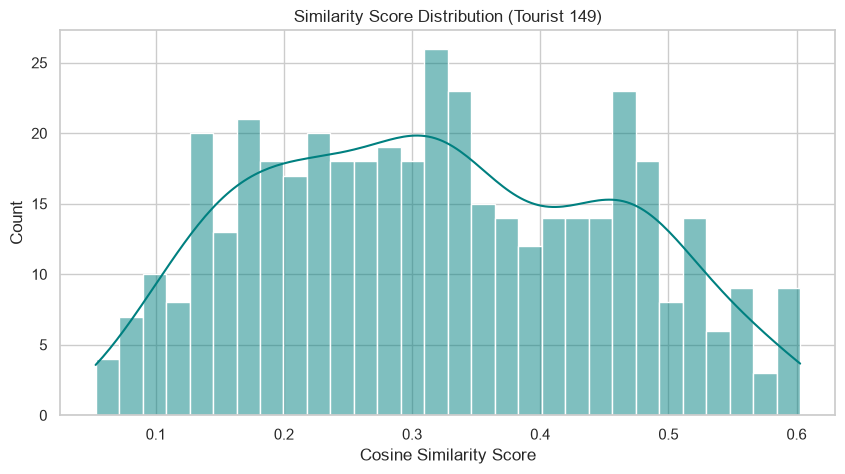

In [6]:
print("Computing cosine similarity between user profile and all attractions...")
scores = compute_similarity(profile, tfidf_matrix)
print(f"Total similarity scores computed: {len(scores)}")
print(f"Similarity Stats - Min: {scores.min():.4f}, Max: {scores.max():.4f}, Mean: {scores.mean():.4f}")

# Plot similarity scores distribution
plt.figure(figsize=(10, 5))
sns.histplot(scores, kde=True, bins=30, color="teal")
plt.title(f"Similarity Score Distribution (Tourist {sample_user_id})")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Count")
plt.show()

### 7. Top-N Recommendation Generation & Visited-Attraction Filtering
We call `recommend_attractions()` to obtain a ranked Top-10 recommendation list. We verify that none of the recommended attractions overlap with the user's historical interaction records.

In [7]:
print(f"Generating Top-10 recommendations for tourist_id={sample_user_id}...")
recs = recommend_attractions(
    tourist_id=sample_user_id,
    interactions_df=train_df,
    attraction_df=attraction_df,
    tfidf_matrix=tfidf_matrix,
    attraction_index=attraction_index,
    top_n=10
)
display(recs)

# Verify visited-attraction filtering
visited_uids = set(user_history["attraction_uid"])
recommended_uids = set(recs["attraction_uid"])
overlap = visited_uids.intersection(recommended_uids)
print(f"\nVerification - Visited count: {len(visited_uids)}")
print(f"Verification - Recommended count: {len(recommended_uids)}")
print(f"Verification - Overlap between visited and recommended: {len(overlap)}")
assert len(overlap) == 0, "Error: Visited attraction leaked into recommendation output!"
print("Overlap verification passed: visited attractions successfully excluded.")

Generating Top-10 recommendations for tourist_id=149...


,attraction_uid,attraction_name,attraction_category,city,similarity_score,rank
0,"Yan Dang Shan (Wen Zhou Shi, Zhejiang)",Yan Dang Shan,Natural Scenery,Wen Zhou Shi,0.602852,1
1,"Qian Shan (An Shan Shi, Liaoning)",Qian Shan,Natural Scenery,An Shan Shi,0.602768,2
2,"Shou Xi Hu (Yang Zhou Shi, Jiangsu)",Shou Xi Hu,Natural Scenery,Yang Zhou Shi,0.600272,3
3,"Hang Zhou Xi Xi Shi Di (Hang Zhou Shi, Zhejiang)",Hang Zhou Xi Xi Shi Di,Natural Scenery,Hang Zhou Shi,0.596542,4
4,"Tian Mu Hu (Chang Zhou Shi, Jiangsu)",Tian Mu Hu,Natural Scenery,Chang Zhou Shi,0.595075,5
5,"Huang Shan (Huang Shan Shi, Anhui)",Huang Shan,Natural Scenery,Huang Shan Shi,0.588637,6
6,"Qu Zhou Jiang Lang Shan (Qu Zhou Shi, Zhejiang)",Qu Zhou Jiang Lang Shan,Natural Scenery,Qu Zhou Shi,0.578630,7
7,"Tian Tang Zhai (Lu An Shi, Anhui)",Tian Tang Zhai,Natural Scenery,Lu An Shi,0.572071,8
8,"Mo Gan Shan (Hu Zhou Shi, Zhejiang)",Mo Gan Shan,Natural Scenery,Hu Zhou Shi,0.569889,9
9,"Bai Yun Shan (Luo Yang Shi, Henan)",Bai Yun Shan,Natural Scenery,Luo Yang Shi,0.566174,10



Verification - Visited count: 18
Verification - Recommended count: 10
Verification - Overlap between visited and recommended: 0
Overlap verification passed: visited attractions successfully excluded.


### 8. Recommendation Output Analysis
To understand the macro characteristics of the CBF recommendations, we generate recommendations for a batch of 50 users and analyze their categories and cities distribution.

/var/folders/hs/vnv38zzd4rgcfjbxsnspr3f80000gn/T/ipykernel_22010/695352191.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/hs/vnv38zzd4rgcfjbxsnspr3f80000gn/T/ipykernel_22010/695352191.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


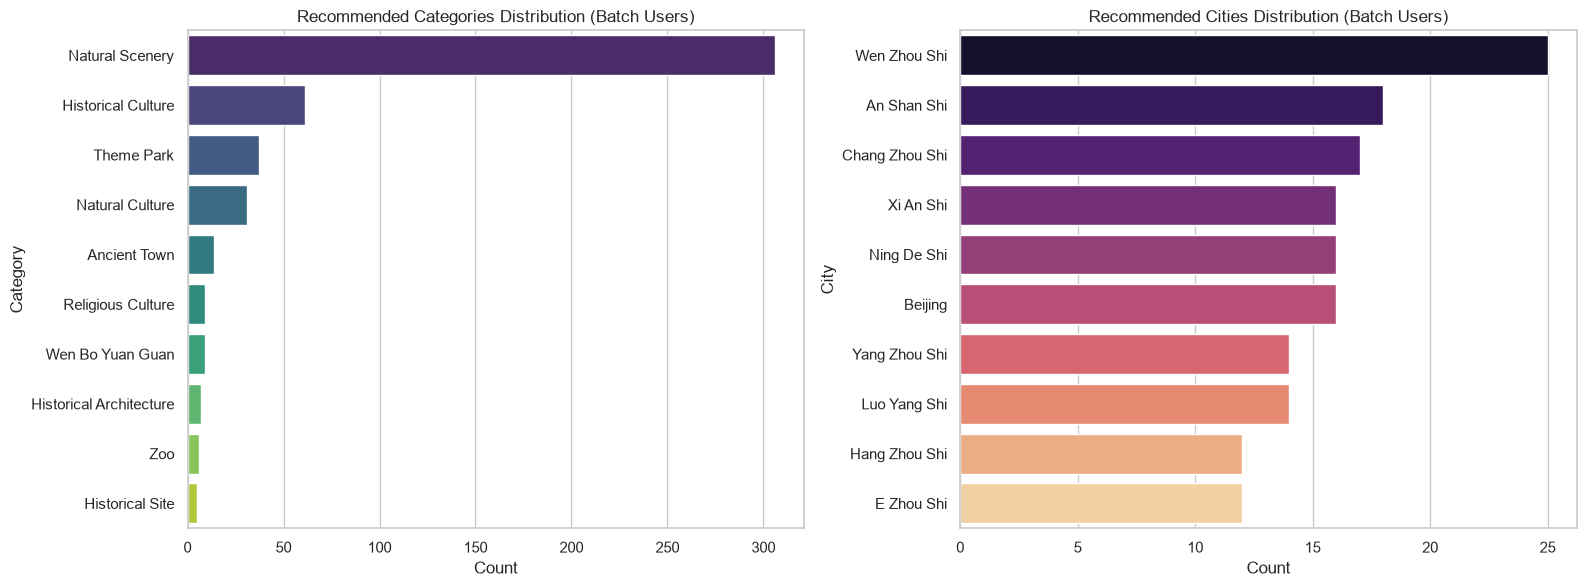

In [8]:
test_users = list(train_df["tourist_id"].unique()[:50])
batch_recs = []
for uid in test_users:
    user_recs = recommend_attractions(
        tourist_id=int(uid),
        interactions_df=train_df,
        attraction_df=attraction_df,
        tfidf_matrix=tfidf_matrix,
        attraction_index=attraction_index,
        top_n=10
    )
    batch_recs.append(user_recs)

batch_df = pd.concat(batch_recs, ignore_index=True)

# Visualizing distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.countplot(
    data=batch_df,
    y="attraction_category",
    order=batch_df["attraction_category"].value_counts().index[:10],
    ax=axes[0],
    palette="viridis"
)
axes[0].set_title("Recommended Categories Distribution (Batch Users)")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("Category")

sns.countplot(
    data=batch_df,
    y="city",
    order=batch_df["city"].value_counts().index[:10],
    ax=axes[1],
    palette="magma"
)
axes[1].set_title("Recommended Cities Distribution (Batch Users)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("City")

plt.tight_layout()
plt.show()

### 9. Edge Cases Inspection
We check two edge cases:
1. **Cold Start (New User)**: The user is completely absent from the training set.
2. **No Positive Ratings**: The user has ratings, but none meet the positive threshold of `>= 4.0`.

In [9]:
# Case A: Cold-start user
cold_user_id = 99999
print(f"Generating recommendations for cold-start user (tourist_id={cold_user_id})...")
cold_recs = recommend_attractions(
    tourist_id=cold_user_id,
    interactions_df=train_df,
    attraction_df=attraction_df,
    tfidf_matrix=tfidf_matrix,
    attraction_index=attraction_index,
    top_n=10
)
print(f"Returned DataFrame Shape: {cold_recs.shape}")
display(cold_recs)

# Case B: User with no positive ratings (ratings < 4.0)
ratings_per_user = train_df.groupby("tourist_id")["rating"].max()
low_rating_users = ratings_per_user[ratings_per_user < 4.0]
if not low_rating_users.empty:
    low_user_id = int(low_rating_users.index[0])
    max_rating = low_rating_users.iloc[0]
    print(f"\nGenerating recommendations for tourist_id={low_user_id} (max rating in train is {max_rating} < 4.0)...")
    low_recs = recommend_attractions(
        tourist_id=low_user_id,
        interactions_df=train_df,
        attraction_df=attraction_df,
        tfidf_matrix=tfidf_matrix,
        attraction_index=attraction_index,
        top_n=10
    )
    print(f"Returned DataFrame Shape: {low_recs.shape}")
    display(low_recs)

Generating recommendations for cold-start user (tourist_id=99999)...
Returned DataFrame Shape: (0, 6)


,attraction_uid,attraction_name,attraction_category,city,similarity_score,rank



Generating recommendations for tourist_id=10000 (max rating in train is 3.9 < 4.0)...
Returned DataFrame Shape: (0, 6)


,attraction_uid,attraction_name,attraction_category,city,similarity_score,rank


* **TF-IDF Sparsity**: The TF-IDF matrix is highly sparse (density is below 1%). This is expected for textual and categorical content representations.
* **Feature Biasing**: By duplicating critical columns like categories and levels, the model correctly prioritizes matching on these core attributes.
* **Cold-Start Handling**: Returning a clean, empty DataFrame with matching column schemas prevents downstream code failures during cold starts.
* **Semantic Concentration**: Recommended items show concentration in category and location matching the target user's profile, validating preference propagation.